In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

project_root = os.path.dirname(os.getcwd())
data_dir = os.path.join(project_root, 'data')
charts_dir = os.path.join(project_root, 'outputs', 'charts')
os.makedirs(data_dir, exist_ok=True)
os.makedirs(charts_dir, exist_ok=True)

print("Project root:", project_root)
print("Data dir:", data_dir)
print("Charts dir:", charts_dir)

Project root: C:\Users\Nikhil\OneDrive\Desktop\Thales_Manufacturing_Analytics
Data dir: C:\Users\Nikhil\OneDrive\Desktop\Thales_Manufacturing_Analytics\data
Charts dir: C:\Users\Nikhil\OneDrive\Desktop\Thales_Manufacturing_Analytics\outputs\charts


In [2]:
df = pd.read_csv(os.path.join(data_dir, 'Thales_Group_Manufacturing.csv'))

df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Timestamp'],
                                 format='%d-%m-%Y %H:%M:%S')
df = df.sort_values('datetime').reset_index(drop=True)
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name()
df['week'] = df['datetime'].dt.isocalendar().week.astype(int)

print("Shape:", df.shape)
print("Date range:", df['datetime'].min(), "to", df['datetime'].max())
print("Unique machines:", df['Machine_ID'].nunique())
print("\nNulls:\n", df.isnull().sum())
df.head()

Shape: (100000, 18)
Date range: 2025-01-01 00:00:00 to 2025-03-10 10:39:00
Unique machines: 50

Nulls:
 Date                             0
Timestamp                        0
Machine_ID                       0
Operation_Mode                   0
Temperature_C                    0
Vibration_Hz                     0
Power_Consumption_kW             0
Network_Latency_ms               0
Packet_Loss_%                    0
Quality_Control_Defect_Rate_%    0
Production_Speed_units_per_hr    0
Predictive_Maintenance_Score     0
Error_Rate_%                     0
Efficiency_Status                0
datetime                         0
hour                             0
day_of_week                      0
week                             0
dtype: int64


,Date,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status,datetime,hour,day_of_week,week
0,2025-01-01,00:00:00,39,Idle,74.138,3.501,8.612,10.651,0.208,7.751,477.657,0.345,14.965,Low,2025-01-01 00:00:00,0,Wednesday,1
1,2025-01-01,00:01:00,29,Active,84.265,3.356,2.269,29.112,2.228,4.989,398.175,0.770,7.678,Low,2025-01-01 00:01:00,0,Wednesday,1
2,2025-01-01,00:02:00,15,Active,44.280,2.080,6.144,18.357,1.639,0.457,108.075,0.987,8.198,Low,2025-01-01 00:02:00,0,Wednesday,1
3,2025-01-01,00:03:00,43,Active,40.569,0.298,4.068,29.154,1.161,4.583,329.579,0.983,2.741,Medium,2025-01-01 00:03:00,0,Wednesday,1
4,2025-01-01,00:04:00,8,Idle,75.064,0.346,6.226,34.029,4.797,2.288,159.114,0.573,12.101,Low,2025-01-01 00:04:00,0,Wednesday,1


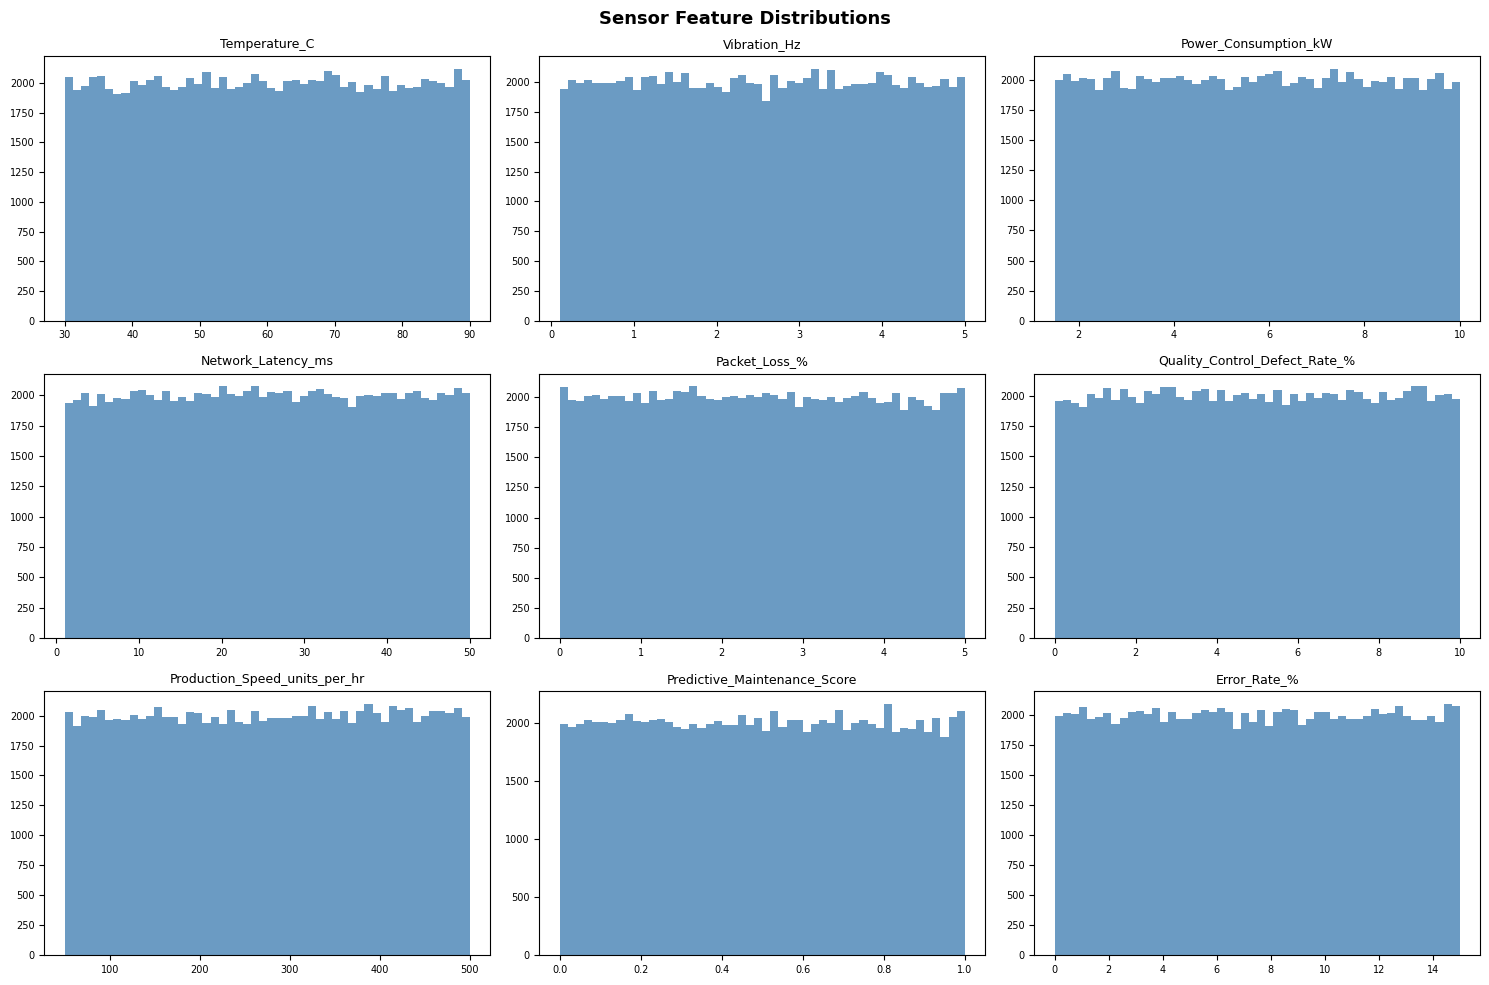

In [3]:
sensor_cols = ['Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW',
               'Network_Latency_ms', 'Packet_Loss_%',
               'Quality_Control_Defect_Rate_%',
               'Production_Speed_units_per_hr',
               'Predictive_Maintenance_Score', 'Error_Rate_%']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for i, col in enumerate(sensor_cols):
    ax = axes[i // 3, i % 3]
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)

plt.suptitle('Sensor Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'fig1_sensor_distributions.png'), dpi=150)
plt.show()

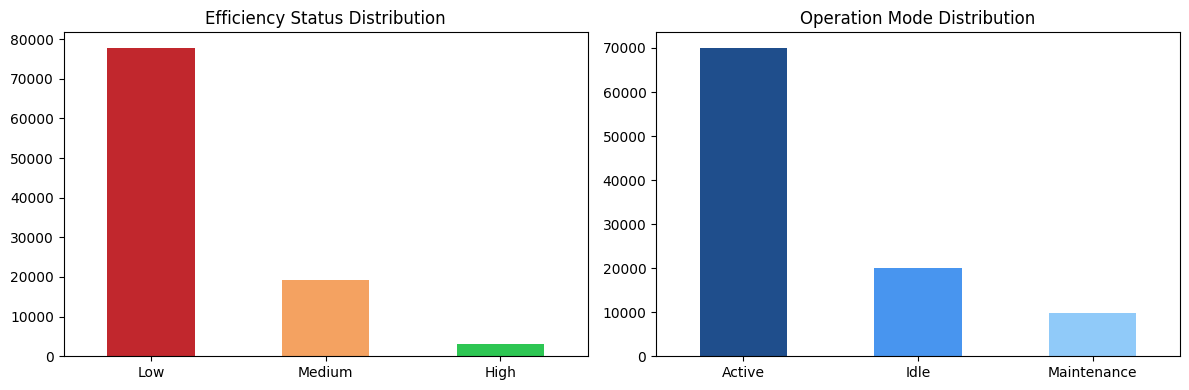

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Efficiency_Status'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#c1272d','#f4a261','#2dc653'], edgecolor='none')
axes[0].set_title('Efficiency Status Distribution')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

df['Operation_Mode'].value_counts().plot(kind='bar', ax=axes[1],
    color=['#1f4e8c','#4895ef','#90caf9'], edgecolor='none')
axes[1].set_title('Operation Mode Distribution')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'fig2_status_distributions.png'), dpi=150)
plt.show()

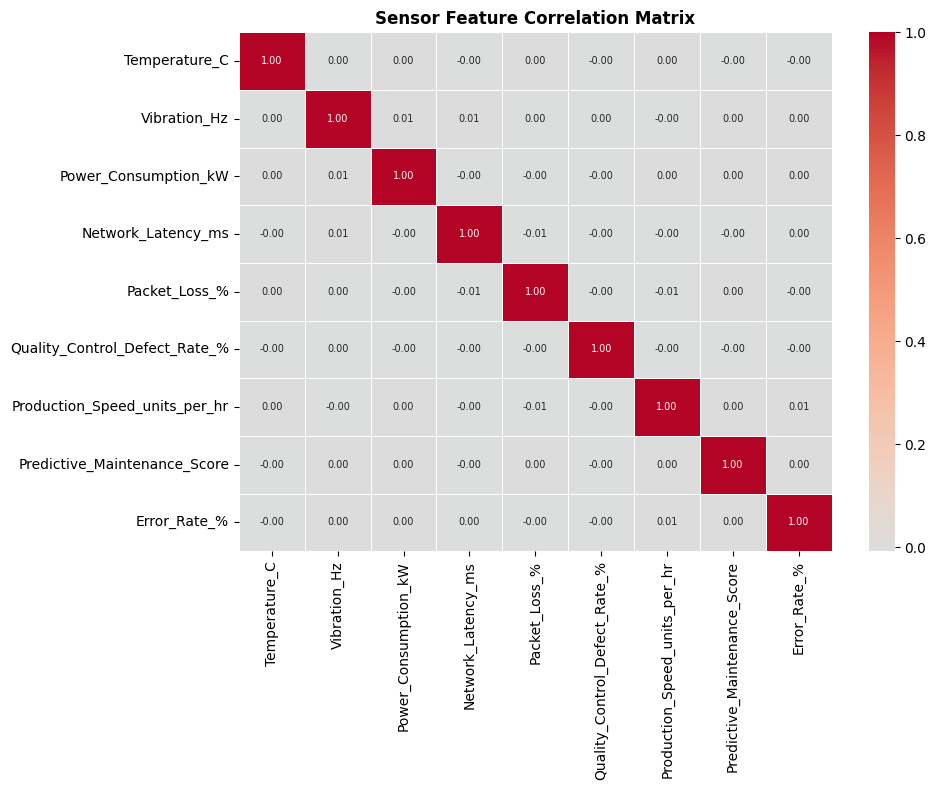

In [5]:
corr = df[sensor_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Sensor Feature Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'fig3_correlation_matrix.png'), dpi=150)
plt.show()

Efficiency_Status                 High      Low   Medium
Temperature_C                   60.232   60.006   60.154
Vibration_Hz                     2.548    2.550    2.552
Power_Consumption_kW             5.718    5.743    5.762
Network_Latency_ms              25.334   25.562   25.566
Packet_Loss_%                    2.528    2.494    2.487
Quality_Control_Defect_Rate_%    4.930    5.017    4.989
Production_Speed_units_per_hr  450.791  254.854  334.125
Predictive_Maintenance_Score     0.495    0.500    0.498
Error_Rate_%                     1.007    8.930    2.733


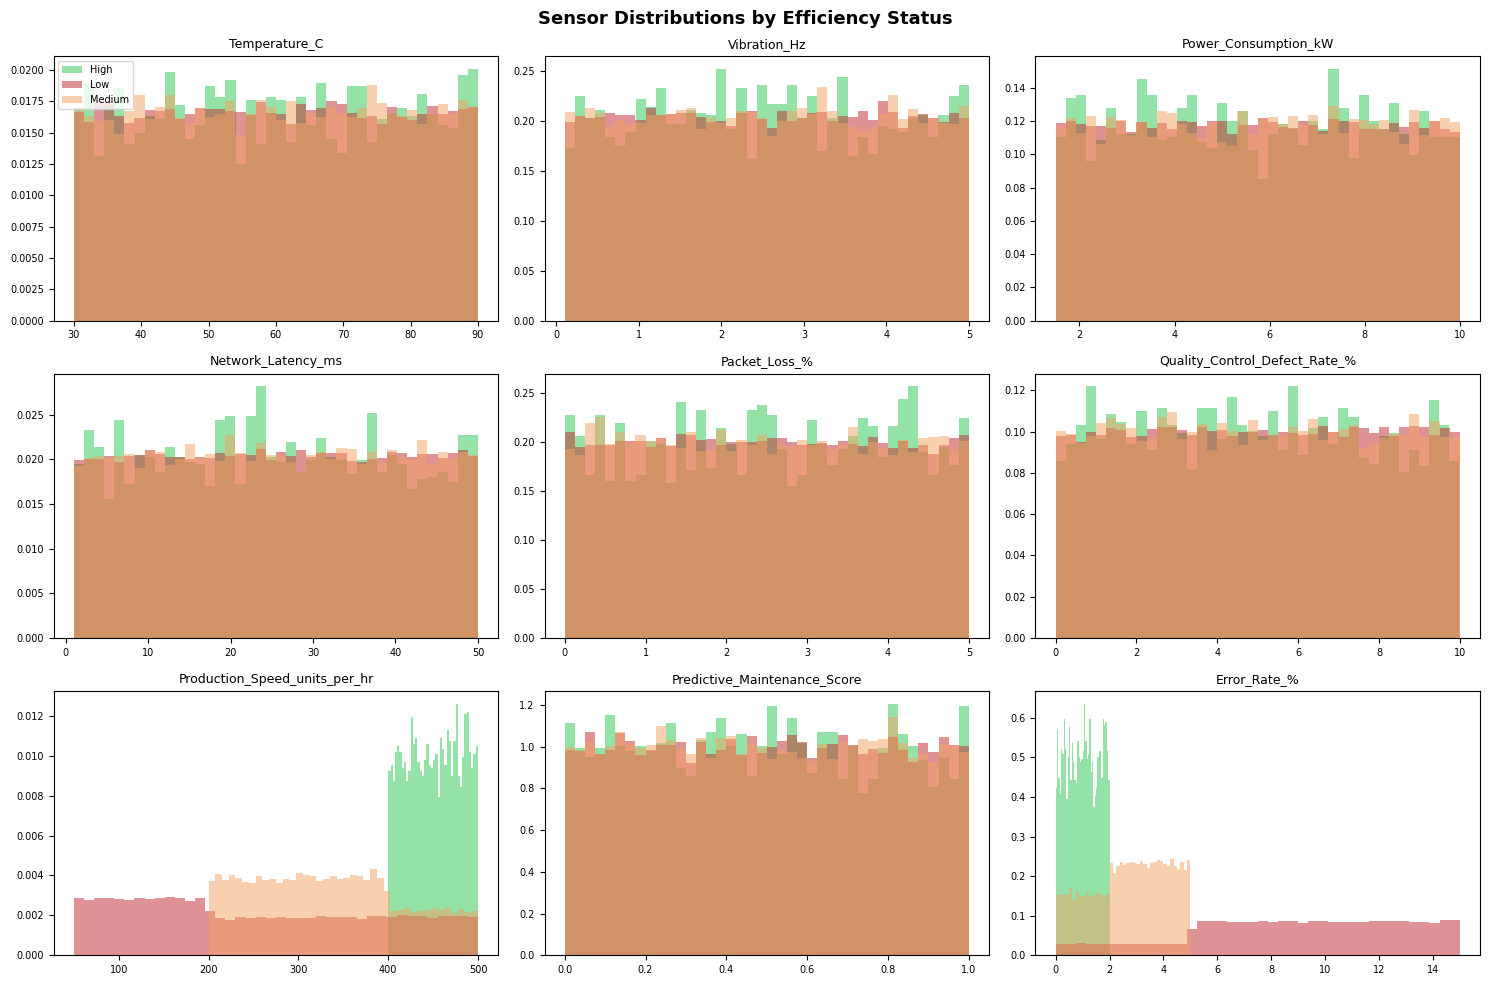

In [6]:
mean_by_status = df.groupby('Efficiency_Status')[sensor_cols].mean()
print(mean_by_status.T.round(3))

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
colors = {'High': '#2dc653', 'Medium': '#f4a261', 'Low': '#c1272d'}

for i, col in enumerate(sensor_cols):
    ax = axes[i // 3, i % 3]
    for status, grp in df.groupby('Efficiency_Status'):
        ax.hist(grp[col], bins=40, alpha=0.5, label=status,
                color=colors[status], edgecolor='none', density=True)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle('Sensor Distributions by Efficiency Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'fig4_sensor_by_efficiency.png'), dpi=150)
plt.show()

In [7]:
sensor_cols = ['Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW',
               'Network_Latency_ms', 'Packet_Loss_%',
               'Quality_Control_Defect_Rate_%', 'Production_Speed_units_per_hr',
               'Predictive_Maintenance_Score', 'Error_Rate_%']

df = df.sort_values(['Machine_ID', 'datetime']).reset_index(drop=True)

window = 60

for col in sensor_cols:
    grouped = df.groupby('Machine_ID')[col]
    df[f'{col}_rolling_mean'] = grouped.transform(
        lambda x: x.rolling(window=window, min_periods=10).mean()
    )
    df[f'{col}_rolling_std'] = grouped.transform(
        lambda x: x.rolling(window=window, min_periods=10).std().fillna(1)
    )
    df[f'{col}_deviation'] = (
        (df[col] - df[f'{col}_rolling_mean']) / df[f'{col}_rolling_std']
    ).fillna(0)

print("Rolling baseline features created.")
print("New columns added:", [c for c in df.columns if 'deviation' in c])

Rolling baseline features created.
New columns added: ['Temperature_C_deviation', 'Vibration_Hz_deviation', 'Power_Consumption_kW_deviation', 'Network_Latency_ms_deviation', 'Packet_Loss_%_deviation', 'Quality_Control_Defect_Rate_%_deviation', 'Production_Speed_units_per_hr_deviation', 'Predictive_Maintenance_Score_deviation', 'Error_Rate_%_deviation']


In [8]:
df['vibration_power_ratio'] = df['Vibration_Hz'] / (df['Power_Consumption_kW'] + 0.001)

df['error_defect_combined'] = (
    df['Error_Rate_%'] * df['Quality_Control_Defect_Rate_%']
)

df['network_stress_index'] = (
    df['Network_Latency_ms'] * (1 + df['Packet_Loss_%'])
)

df['maintenance_score_inverse'] = 1 - df['Predictive_Maintenance_Score']

df['temp_vibration_stress'] = (
    df['Temperature_C'] * df['Vibration_Hz']
) / 100

df['speed_efficiency_ratio'] = df['Production_Speed_units_per_hr'] / 500

print("Derived ratio features created.")
print(df[['vibration_power_ratio','error_defect_combined',
          'network_stress_index','maintenance_score_inverse',
          'temp_vibration_stress','speed_efficiency_ratio']].describe())

Derived ratio features created.
       vibration_power_ratio  error_defect_combined  network_stress_index  \
count          100000.000000          100000.000000         100000.000000   
mean                0.568677              37.567998             89.136127   
std                 0.493288              33.060048             64.634044   
min                 0.010281               0.000000              1.027072   
25%                 0.232484              10.200411             37.144097   
50%                 0.441408              28.088315             74.254570   
75%                 0.728932              57.514834            129.441923   
max                 3.284106             149.141222            299.140135   

       maintenance_score_inverse  temp_vibration_stress  \
count              100000.000000          100000.000000   
mean                    0.500616               1.531182   
std                     0.288814               0.988745   
min                     0.000000      

In [9]:
df['error_rate_trend'] = df.groupby('Machine_ID')['Error_Rate_%'].transform(
    lambda x: x.rolling(window=30, min_periods=5).mean() -
              x.rolling(window=120, min_periods=20).mean()
).fillna(0)

df['maintenance_score_decay'] = df.groupby('Machine_ID')['Predictive_Maintenance_Score'].transform(
    lambda x: x.rolling(window=30, min_periods=5).mean() -
              x.rolling(window=120, min_periods=20).mean()
).fillna(0)

print("Trend features created.")
print(df[['error_rate_trend','maintenance_score_decay']].describe())

Trend features created.
       error_rate_trend  maintenance_score_decay
count     100000.000000            100000.000000
mean           0.000871                 0.000159
std            0.688596                 0.045476
min           -2.823692                -0.238042
25%           -0.458898                -0.029733
50%            0.000000                 0.000000
75%            0.461045                 0.030550
max            2.671250                 0.198575


In [10]:
feature_cols = (
    [f'{col}_deviation' for col in sensor_cols] +
    ['vibration_power_ratio', 'error_defect_combined',
     'network_stress_index', 'maintenance_score_inverse',
     'temp_vibration_stress', 'speed_efficiency_ratio',
     'error_rate_trend', 'maintenance_score_decay']
)

active_df = df[df['Operation_Mode'] == 'Active'].copy()

from sklearn.preprocessing import StandardScaler

X = active_df[feature_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)
print("Total features:", len(feature_cols))
print("Features used:", feature_cols)

Feature matrix shape: (70054, 17)
Total features: 17
Features used: ['Temperature_C_deviation', 'Vibration_Hz_deviation', 'Power_Consumption_kW_deviation', 'Network_Latency_ms_deviation', 'Packet_Loss_%_deviation', 'Quality_Control_Defect_Rate_%_deviation', 'Production_Speed_units_per_hr_deviation', 'Predictive_Maintenance_Score_deviation', 'Error_Rate_%_deviation', 'vibration_power_ratio', 'error_defect_combined', 'network_stress_index', 'maintenance_score_inverse', 'temp_vibration_stress', 'speed_efficiency_ratio', 'error_rate_trend', 'maintenance_score_decay']


In [11]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_scaled)

active_df['anomaly_label'] = iso_forest.predict(X_scaled)
active_df['anomaly_score_raw'] = iso_forest.score_samples(X_scaled)

active_df['anomaly_score'] = (
    (active_df['anomaly_score_raw'] - active_df['anomaly_score_raw'].min()) /
    (active_df['anomaly_score_raw'].max() - active_df['anomaly_score_raw'].min())
)
active_df['anomaly_score'] = 1 - active_df['anomaly_score']

print("Isolation Forest trained.")
print("Anomaly label distribution (-1=anomaly, 1=normal):")
print(active_df['anomaly_label'].value_counts())
print()
print("Anomaly score stats:")
print(active_df['anomaly_score'].describe())

Isolation Forest trained.
Anomaly label distribution (-1=anomaly, 1=normal):
anomaly_label
 1    66551
-1     3503
Name: count, dtype: int64

Anomaly score stats:
count    70054.000000
mean         0.376279
std          0.129568
min          0.000000
25%          0.283610
50%          0.368074
75%          0.459302
max          1.000000
Name: anomaly_score, dtype: float64


In [12]:
def assign_risk(score):
    if score >= 0.7:
        return 'High'
    elif score >= 0.4:
        return 'Medium'
    else:
        return 'Low'

active_df['risk_level'] = active_df['anomaly_score'].apply(assign_risk)

print("Risk Level Distribution:")
print(active_df['risk_level'].value_counts())
print()
print("Risk % breakdown:")
print((active_df['risk_level'].value_counts() / len(active_df) * 100).round(2))

Risk Level Distribution:
risk_level
Low       41833
Medium    27390
High        831
Name: count, dtype: int64

Risk % breakdown:
risk_level
Low       59.72
Medium    39.10
High       1.19
Name: count, dtype: float64


In [13]:
result_cols = ['anomaly_label', 'anomaly_score_raw', 'anomaly_score', 'risk_level']
df = df.merge(
    active_df[['datetime', 'Machine_ID'] + result_cols],
    on=['datetime', 'Machine_ID'],
    how='left'
)

df['risk_level'] = df['risk_level'].fillna('Not Active')
df['anomaly_score'] = df['anomaly_score'].fillna(0)

print("Merged back. Shape:", df.shape)
print("Risk level distribution (all records):")
print(df['risk_level'].value_counts())

Merged back. Shape: (100022, 57)
Risk level distribution (all records):
risk_level
Low           41852
Not Active    29932
Medium        27407
High            831
Name: count, dtype: int64


In [14]:
high_risk_machines = (
    active_df[active_df['risk_level'] == 'High']
    .groupby('Machine_ID')
    .agg(
        high_risk_count=('risk_level', 'count'),
        avg_anomaly_score=('anomaly_score', 'mean'),
        max_anomaly_score=('anomaly_score', 'max')
    )
    .sort_values('high_risk_count', ascending=False)
    .reset_index()
)

print("Top 15 High Risk Machines:")
print(high_risk_machines.head(15))

Top 15 High Risk Machines:
    Machine_ID  high_risk_count  avg_anomaly_score  max_anomaly_score
0           18               27           0.748303           0.857020
1           32               27           0.766917           0.889101
2            3               25           0.756221           0.859012
3           33               22           0.745335           0.815857
4           24               22           0.750120           0.895000
5           44               21           0.761893           0.893238
6           14               21           0.737959           0.814600
7           20               21           0.754993           0.881198
8            7               20           0.750969           0.927774
9           47               19           0.749546           0.953125
10          28               19           0.768055           1.000000
11           1               18           0.742377           0.906283
12          46               18           0.739190           0.

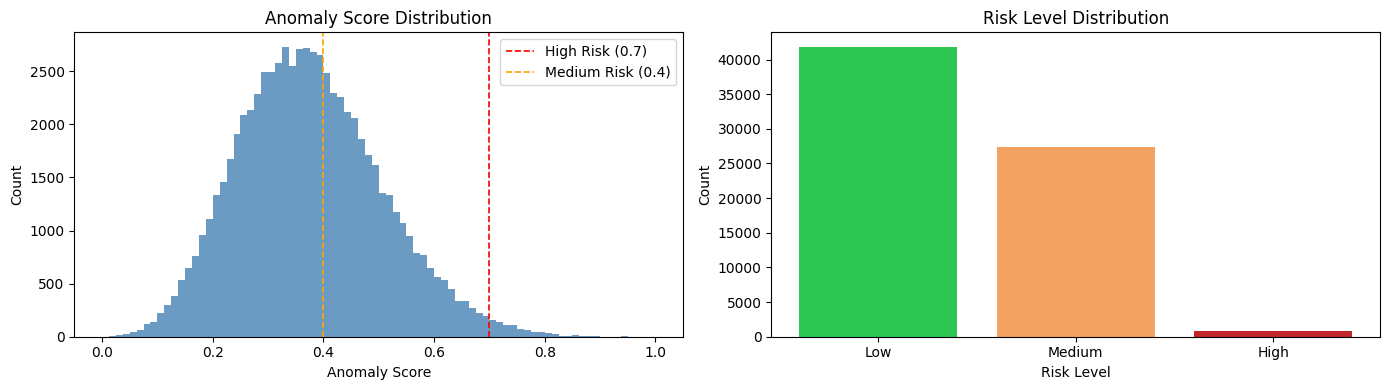

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(active_df['anomaly_score'], bins=80,
             color='steelblue', edgecolor='none', alpha=0.8)
axes[0].axvline(0.7, color='red', linestyle='--', linewidth=1.2, label='High Risk (0.7)')
axes[0].axvline(0.4, color='orange', linestyle='--', linewidth=1.2, label='Medium Risk (0.4)')
axes[0].set_title('Anomaly Score Distribution')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Count')
axes[0].legend()

colors = {'Low': '#2dc653', 'Medium': '#f4a261', 'High': '#c1272d'}
risk_counts = active_df['risk_level'].value_counts()
axes[1].bar(risk_counts.index, risk_counts.values,
            color=[colors[r] for r in risk_counts.index], edgecolor='none')
axes[1].set_title('Risk Level Distribution')
axes[1].set_xlabel('Risk Level')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'fig5_anomaly_distribution.png'), dpi=150)
plt.show()

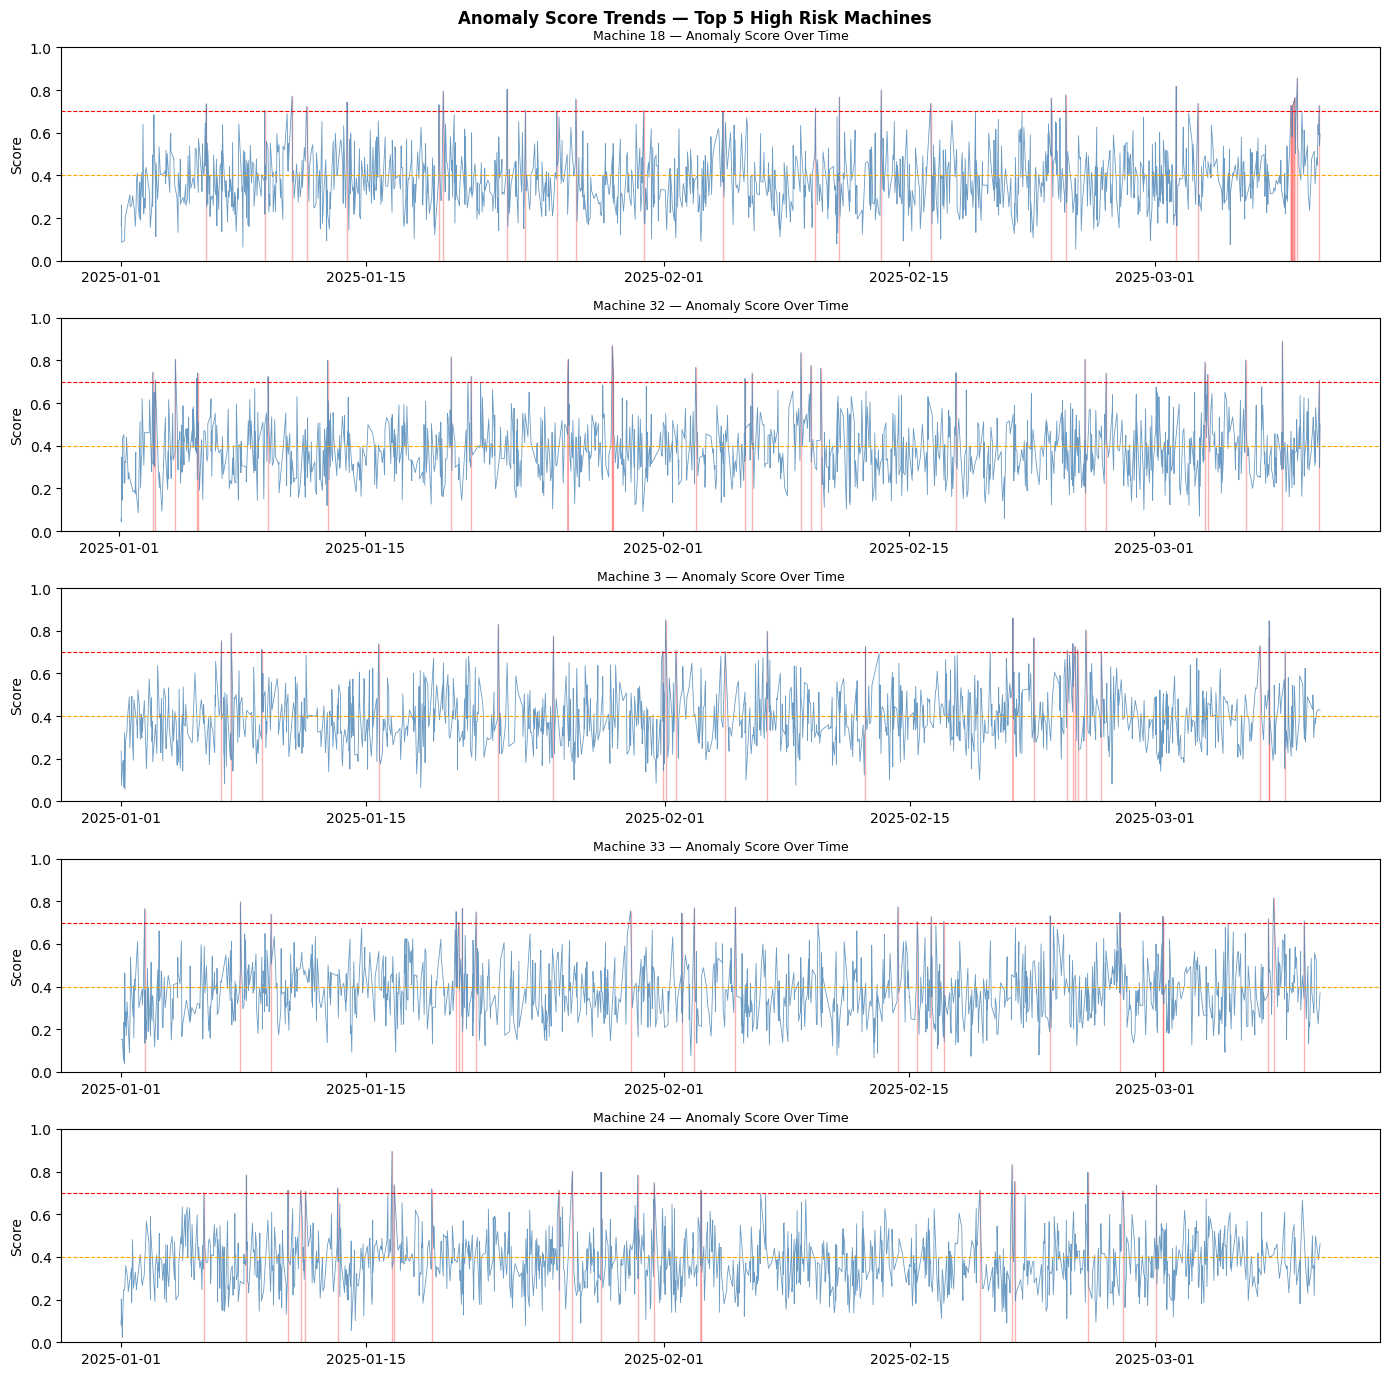

In [16]:
top5_machines = high_risk_machines.head(5)['Machine_ID'].tolist()

fig, axes = plt.subplots(5, 1, figsize=(14, 14))

for i, mid in enumerate(top5_machines):
    mdf = active_df[active_df['Machine_ID'] == mid].sort_values('datetime')
    axes[i].plot(mdf['datetime'], mdf['anomaly_score'],
                 linewidth=0.6, color='steelblue', alpha=0.8)
    axes[i].axhline(0.7, color='red', linestyle='--', linewidth=0.8)
    axes[i].axhline(0.4, color='orange', linestyle='--', linewidth=0.8)
    axes[i].fill_between(mdf['datetime'], mdf['anomaly_score'],
                          where=mdf['anomaly_score'] >= 0.7,
                          color='red', alpha=0.3)
    axes[i].set_title(f'Machine {mid} — Anomaly Score Over Time', fontsize=9)
    axes[i].set_ylabel('Score')
    axes[i].set_ylim(0, 1)

plt.suptitle('Anomaly Score Trends — Top 5 High Risk Machines',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'fig6_anomaly_trends.png'), dpi=150)
plt.show()

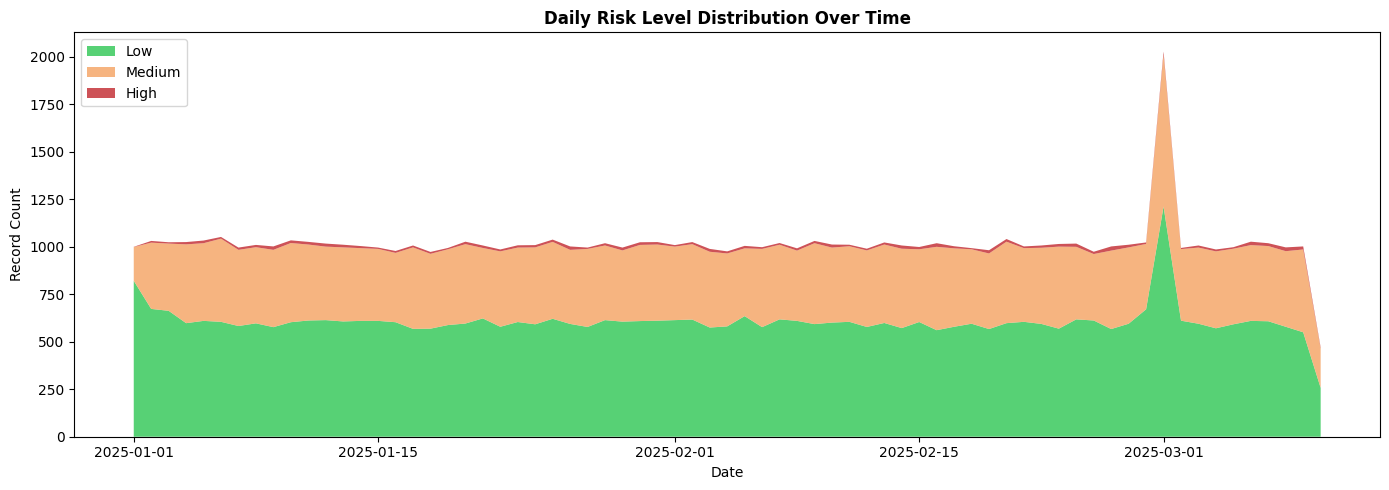

In [17]:
daily_risk = (
    active_df.groupby([active_df['datetime'].dt.date, 'risk_level'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
daily_risk.columns.name = None
daily_risk['datetime'] = pd.to_datetime(daily_risk['datetime'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(daily_risk['datetime'],
             daily_risk.get('Low', 0),
             daily_risk.get('Medium', 0),
             daily_risk.get('High', 0),
             labels=['Low', 'Medium', 'High'],
             colors=['#2dc653', '#f4a261', '#c1272d'],
             alpha=0.8)
ax.set_title('Daily Risk Level Distribution Over Time', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Record Count')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'fig7_temporal_risk.png'), dpi=150)
plt.show()

In [18]:
df['month_str'] = df['datetime'].dt.to_period('M').astype(str)
df['date_str'] = df['datetime'].dt.date.astype(str)

df.to_csv(os.path.join(data_dir, 'processed_manufacturing_data.csv'), index=False)
active_df.to_csv(os.path.join(data_dir, 'active_anomaly_data.csv'), index=False)
high_risk_machines.to_csv(os.path.join(data_dir, 'high_risk_machines.csv'), index=False)

print("All files saved successfully!")
print("processed_manufacturing_data.csv:", df.shape)
print("active_anomaly_data.csv:", active_df.shape)
print("high_risk_machines.csv:", high_risk_machines.shape)

All files saved successfully!
processed_manufacturing_data.csv: (100022, 59)
active_anomaly_data.csv: (70054, 57)
high_risk_machines.csv: (50, 4)


In [21]:
print("=== PAPER STATS ===")
print(f"Total records: {len(df)}")
print(f"Active records: {len(active_df)}")
print(f"Anomalies detected: {(active_df['anomaly_label']==-1).sum()}")
print(f"High risk: {(active_df['risk_level']=='High').sum()}")
print(f"Medium risk: {(active_df['risk_level']=='Medium').sum()}")
print(f"Machines: {df['Machine_ID'].nunique()}")
print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Avg anomaly score: {active_df['anomaly_score'].mean():.4f}")
print(f"Machines with high risk: {active_df[active_df['risk_level']=='High']['Machine_ID'].nunique()}")
print(f"Top machine by high risk events: Machine {high_risk_machines.iloc[0]['Machine_ID']} with {high_risk_machines.iloc[0]['high_risk_count']} events")
print(f"Highest peak score: {active_df['anomaly_score'].max():.4f}")
print()
print("Feature importance (mean absolute deviation per feature):")
feature_importance = pd.Series(
    np.abs(active_df[feature_cols].values).mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)
print(feature_importance.head(10))

=== PAPER STATS ===
Total records: 100022
Active records: 70054
Anomalies detected: 3503
High risk: 831
Medium risk: 27390
Machines: 50
Date range: 2025-01-01 00:00:00 to 2025-03-10 10:39:00
Avg anomaly score: 0.3763
Machines with high risk: 50
Top machine by high risk events: Machine 18.0 with 27.0 events
Highest peak score: 1.0000

Feature importance (mean absolute deviation per feature):
network_stress_index                       89.164850
error_defect_combined                      37.532584
temp_vibration_stress                       1.533576
Quality_Control_Defect_Rate_%_deviation     0.855385
Production_Speed_units_per_hr_deviation     0.854099
Vibration_Hz_deviation                      0.853463
Error_Rate_%_deviation                      0.853217
Predictive_Maintenance_Score_deviation      0.853134
Power_Consumption_kW_deviation              0.853130
Packet_Loss_%_deviation                     0.852968
dtype: float64
